# Clustering K-Means de Centros Poblados del Perú

**Tema:** Regionalización geográfica de centros poblados mediante K-Means.

- **Problema:** ¿se pueden agrupar los centros poblados del Perú en zonas geográficas coherentes usando solo su ubicación y altitud, sin usar las etiquetas administrativas (departamento)?
- **Técnica:** K-Means
- **Método:** estandarizar variables → método del codo para elegir k → ajustar K-Means final → comparar clusters contra departamentos reales.
- **Contexto:** geografía computacional / regionalización automática a partir de datos abiertos del INEI/IGN.

> **Sobre los datos:** este notebook usa el shapefile real `CP_P.shp` (INEI/IGN) junto al diccionario `DICCIONARIO_CP_P` (columnas `DEP`, `PROV`, `DIST`, `NOMCP`, `CAPITAL`, `CON_IE`, `NIVEL`, `Z`, `XGD`, `YGD`) — **153,400 centros poblados** a nivel nacional. Si el shapefile real no está disponible, el notebook cae automáticamente a un dataset ficticio de respaldo con la misma estructura, solo para poder probar el flujo.

## 1. Preparación del entorno

In [1]:
!apt-get install -y gnuplot -qq


## 2. Carga de datos

Intenta cargar, en este orden: (1) `centros_poblados.csv` ya exportado, (2) el shapefile real `CP_P.shp` (INEI/IGN, 153,400 registros), o (3) si ninguno está disponible, genera un dataset ficticio de respaldo con la misma estructura del diccionario real.

In [2]:
import os
import numpy as np
import pandas as pd

np.random.seed(42)

def generar_datos_ficticios():
    """Genera un dataset ficticio con la misma estructura del diccionario
    real CP_P (INEI/IGN): DEP, PROV, DIST, NOMCP, CAPITAL, CON_IE, NIVEL,
    Z, XGD, YGD. Geografía aproximada del Perú. Solo se usa como respaldo
    si no se encuentra ni 'centros_poblados.csv' ni el shapefile real
    'CP_P.shp'."""
    rng = np.random.default_rng(42)

    # (lon, lat, región, n_puntos, spread_lon, spread_lat, altitud_media, altitud_sd)
    departamentos = {
        "TUMBES":       (-80.45, -3.57,  "Costa",    900,  0.25, 0.25,   40,   30),
        "PIURA":        (-80.63, -5.19,  "Costa",   3200,  0.55, 0.55,   80,   60),
        "LAMBAYEQUE":   (-79.90, -6.70,  "Costa",   1800,  0.35, 0.35,   60,   40),
        "LA LIBERTAD":  (-78.90, -7.90,  "Costa",   2600,  0.60, 0.60,  400,  500),
        "ANCASH":       (-77.53, -9.53,  "Sierra",  3400,  0.70, 0.90, 3200, 900),
        "LIMA":         (-77.03,-12.05,  "Costa",   4200,  0.60, 0.60,  350,  600),
        "ICA":          (-75.73,-14.07,  "Costa",   1300,  0.40, 0.55,  250,  300),
        "AREQUIPA":     (-71.54,-16.40,  "Sierra",  2600,  0.90, 1.00, 2400,1200),
        "MOQUEGUA":     (-70.93,-17.19,  "Sierra",   700,  0.45, 0.45, 2200,1100),
        "TACNA":        (-70.25,-18.01,  "Sierra",   800,  0.40, 0.35, 2000, 900),
        "CAJAMARCA":    (-78.50, -7.16,  "Sierra",  3600,  0.75, 0.80, 2700, 700),
        "AMAZONAS":     (-77.87, -6.23,  "Selva",   1200,  0.60, 0.70, 1500, 900),
        "SAN MARTIN":   (-76.97, -6.48,  "Selva",   1800,  0.65, 0.90,  450, 350),
        "LORETO":       (-73.25, -3.75,  "Selva",   1600,  2.20, 2.60,  130,  60),
        "HUANUCO":      (-76.24, -9.93,  "Sierra",  1900,  0.65, 0.75, 2100,1000),
        "PASCO":        (-76.26,-10.68,  "Sierra",   900,  0.45, 0.55, 3500, 700),
        "JUNIN":        (-75.20,-11.15,  "Sierra",  2400,  0.70, 0.85, 3300, 900),
        "HUANCAVELICA": (-74.97,-12.79,  "Sierra",  1500,  0.55, 0.65, 3700, 500),
        "AYACUCHO":     (-74.22,-13.16,  "Sierra",  2000,  0.70, 0.80, 3100,1000),
        "APURIMAC":     (-72.88,-13.63,  "Sierra",  1300,  0.55, 0.60, 3200, 700),
        "CUSCO":        (-71.97,-13.53,  "Sierra",  3000,  0.85, 0.90, 3200,1200),
        "PUNO":         (-70.02,-15.84,  "Sierra",  3200,  0.90, 1.10, 3900, 600),
        "UCAYALI":      (-74.55, -8.38,  "Selva",   1000,  1.60, 1.80,  180,  80),
        "MADRE DE DIOS":(-69.19,-12.59,  "Selva",    500,  1.40, 1.40,  250, 100),
    }
    NIVELES = ["I", "P", "S", "K", "L", "E", "D", "G"]

    registros = []
    for dep, (lon0, lat0, region, n, s_lon, s_lat, alt_m, alt_sd) in departamentos.items():
        lons = rng.normal(lon0, s_lon, n)
        lats = rng.normal(lat0, s_lat, n)
        alts = np.clip(rng.normal(alt_m, alt_sd, n), 0, 6000)
        con_ie = rng.choice([0, 1], size=n, p=[0.35, 0.65])
        capital = rng.choice([0, 1, 2, 3], size=n, p=[0.90, 0.02, 0.08, 0.0])
        nivel = rng.choice(NIVELES, size=n)
        for i in range(n):
            registros.append({
                "DEP": dep, "PROV": f"{dep[:4]}-{(i % 15) + 1:02d}",
                "DIST": f"{dep[:3]}D{(i % 40) + 1:03d}",
                "NOMCP": f"CP_{dep[:3]}_{i:05d}",
                "CAPITAL": int(capital[i]), "CON_IE": int(con_ie[i]), "NIVEL": nivel[i],
                "Z": round(float(alts[i]), 1),
                "XGD": round(float(lons[i]), 6), "YGD": round(float(lats[i]), 6),
            })
    return pd.DataFrame(registros)


if os.path.exists("centros_poblados.csv"):
    print("Usando 'centros_poblados.csv' ya existente (dataset real exportado previamente).")
    df = pd.read_csv("centros_poblados.csv")
elif os.path.exists("CP_P.shp"):
    print("Leyendo shapefile real CP_P.shp (INEI/IGN) ...")
    import shapefile
    sf = shapefile.Reader("CP_P.shp", encoding="utf-8")
    registros = [{
        "DEP": r["DEP"], "PROV": r["PROV"], "DIST": r["DIST"], "NOMCP": r["NOMCP"],
        "CAPITAL": r["CAPITAL"], "CON_IE": r["CON_IE"], "NIVEL": r["NIVEL"],
        "Z": r["Z"], "XGD": r["XGD"], "YGD": r["YGD"],
    } for r in sf.iterRecords()]
    df = pd.DataFrame(registros)

    # Limpieza: algunos registros de la base original vienen sin DEP asignado
    # (centros poblados no vigentes / duplicados en el proceso de depuración
    # del INEI/IGN). Se descartan porque no aportan a la comparación contra
    # departamentos reales y podrían distorsionar el crosstab.
    n_antes = len(df)
    df["DEP"] = df["DEP"].str.strip()
    df = df[df["DEP"] != ""].reset_index(drop=True)
    print(f"Registros con DEP vacío descartados: {n_antes - len(df)} de {n_antes}")

    df.to_csv("centros_poblados.csv", index=False)
else:
    print("No se encontró dataset real. Generando dataset FICTICIO (autorizado por el profesor)...")
    df = generar_datos_ficticios()
    df.to_csv("centros_poblados.csv", index=False)

print(df.shape)
print("Departamentos distintos:", df["DEP"].nunique())
df.head()


Leyendo shapefile real CP_P.shp (INEI/IGN) ...


Registros con DEP vacío descartados: 69 de 153400


(153331, 10)
Departamentos distintos: 25


,DEP,PROV,DIST,NOMCP,CAPITAL,CON_IE,NIVEL,Z,XGD,YGD
0,TACNA,JORGE BASADRE,ITE,Icuy,0,0,,22,-71.113285,-17.837672
1,TACNA,JORGE BASADRE,ITE,Punta Picata,0,0,,11,-71.095762,-17.866908
2,TACNA,JORGE BASADRE,ITE,Tacahuay,0,0,,340,-71.099018,-17.799934
3,TACNA,JORGE BASADRE,ITE,Esquilimache,0,0,,161,-71.091930,-17.833363
4,MOQUEGUA,ILO,ILO,Icuy,0,0,,141,-71.128033,-17.811909


## 3. Clustering K-Means

**Técnica:** K-Means sobre longitud, latitud y altitud (`XGD`, `YGD`, `Z`).

Como estas variables están en escalas muy distintas (grados geográficos vs. metros de altitud), primero se **estandarizan** (media 0, desviación 1); si no, la altitud dominaría por completo la distancia euclidiana.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df[["XGD", "YGD", "Z"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables estandarizadas. Media ~0, desviación ~1:")
print(pd.DataFrame(X_scaled, columns=["XGD_z", "YGD_z", "Z_z"]).describe().loc[["mean", "std"]])


Variables estandarizadas. Media ~0, desviación ~1:
             XGD_z         YGD_z           Z_z
mean  2.562441e-15 -2.372631e-16  9.490524e-17
std   1.000003e+00  1.000003e+00  1.000003e+00


## 4. Método del codo — ¿cuántos clusters (k) usar?

Se prueba K-Means con distintos valores de k (2 a 10) y se mide la **inercia** (qué tan compactos quedan los clusters). El "codo" de la curva señala el punto donde agregar más clusters deja de mejorar mucho el resultado — ese es el método para justificar la elección de k, en vez de elegirlo a ojo.

In [4]:
inercias, siluetas = [], []
k_values = list(range(2, 11))
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    idx = np.random.default_rng(0).choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
    siluetas.append(silhouette_score(X_scaled[idx], labels[idx]))

codo_df = pd.DataFrame({"k": k_values, "inercia": inercias, "silueta": siluetas})
codo_df.to_csv("codo_kmeans.csv", index=False)
codo_df


,k,inercia,silueta
0,2,209600.253832,0.467710
1,3,144017.748606,0.408564
2,4,105338.551715,0.438987
3,5,82104.900434,0.416555
4,6,71102.211326,0.391142
5,7,60368.567044,0.407273
6,8,52127.042009,0.411435
7,9,47469.850912,0.366779
8,10,43936.920598,0.349904


In [5]:
# Elegimos k con mejor silhouette score dentro de un rango interpretable (3-6):
# menos de 3 no distingue bien costa/sierra/selva; más de 6 es difícil de explicar.
mejor_idx = codo_df.loc[codo_df["k"].between(3, 6), "silueta"].idxmax()
K_FINAL = int(codo_df.loc[mejor_idx, "k"])
print(f"k elegido: {K_FINAL}")


k elegido: 4


## 5. Ajustar K-Means final e interpretar los clusters

In [6]:
km_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
df["cluster"] = km_final.fit_predict(X_scaled)

# Centroide de cada cluster, en unidades reales (des-estandarizado)
centroides = scaler.inverse_transform(km_final.cluster_centers_)
resumen = pd.DataFrame(centroides, columns=["XGD_centro", "YGD_centro", "Z_centro"])
resumen["n_centros_poblados"] = df["cluster"].value_counts().sort_index().values
resumen["pct"] = (resumen["n_centros_poblados"] / len(df) * 100).round(2)
resumen.index.name = "cluster"
resumen.to_csv("resumen_clusters.csv")
resumen


,XGD_centro,YGD_centro,Z_centro,n_centros_poblados,pct
cluster,,,,,
0,-76.366950,-10.757433,3587.244596,46918,30.60
1,-71.587484,-14.824505,3888.498180,54642,35.64
2,-77.962897,-6.262767,1077.070112,32282,21.05
3,-74.505505,-12.559085,733.427509,19489,12.71


In [7]:
# Comparación contra los departamentos reales: ¿qué tan bien
# "redescubre" K-Means las regiones geográficas sin usar la etiqueta DEP?
cruce = pd.crosstab(df["DEP"], df["cluster"])

# Paleta y etiqueta (departamento dominante) por cluster, reutilizadas
# más abajo en los scripts de GNU Plot para que se adapten automáticamente
# a los datos reales (no quedan fijas a k=4 ni a nombres de región supuestos).
PALETTE = ["#3B7A57", "#377BB5", "#B5451A", "#8E44AD", "#D4AC0D",
           "#16A085", "#C0392B", "#2C3E50", "#7F8C8D", "#E67E22"]
cluster_top_dep = {}

print("Departamentos más frecuentes en cada cluster:")
for c in range(K_FINAL):
    top3 = cruce[c].sort_values(ascending=False).head(3)
    cluster_top_dep[c] = top3.index[0]
    print(f"  Cluster {c}: {', '.join(top3.index)}")

df.to_csv("centros_clusters.csv", index=False)
print("\nCSV exportado para GNU Plot:", df.shape)


Departamentos más frecuentes en cada cluster:
  Cluster 0: ANCASH, HUANCAVELICA, HUANUCO
  Cluster 1: PUNO, CUSCO, AYACUCHO
  Cluster 2: CAJAMARCA, SAN MARTIN, PIURA
  Cluster 3: LIMA, ICA, JUNIN



CSV exportado para GNU Plot: (153331, 11)


### 5.1 Validación cuantitativa y una primera mirada a `CON_IE` / `CAPITAL`

Además de mirar los departamentos dominantes por cluster (arriba), conviene una métrica formal de acuerdo entre el clustering y `DEP`, y una primera exploración descriptiva de `CON_IE` (¿tiene institución educativa?) y `CAPITAL` (¿es capital de distrito/provincia/departamento?) — las dos variables que la sección de Recomendaciones sugiere probar como posibles features adicionales de clustering.

In [8]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ¿Qué tan bien "redescubre" el clustering la partición real por departamento?
# ARI/NMI comparan las dos particiones (cluster vs. DEP) de forma agnóstica
# a cómo se numeran/nombran los clusters.
ari = adjusted_rand_score(df["DEP"], df["cluster"])
nmi = normalized_mutual_info_score(df["DEP"], df["cluster"])
print(f"Adjusted Rand Index (DEP vs. cluster):        {ari:.3f}")
print(f"Normalized Mutual Information (DEP vs. cluster): {nmi:.3f}")

# CON_IE: 1 = el centro poblado cuenta con institución educativa
con_ie_pct = df.groupby("cluster")["CON_IE"].apply(
    lambda s: (s.astype(str) == "1").mean() * 100
).round(1)
print("\n% de centros poblados con institución educativa (CON_IE), por cluster:")
print(con_ie_pct)

# CAPITAL: '0' = no es capital; '1'/'2'/'3' = capital de distrito/provincia/departamento
capital_pct = df.groupby("cluster")["CAPITAL"].apply(
    lambda s: (s.astype(str) != "0").mean() * 100
).round(2)
print("\n% de centros poblados que son alguna capital (CAPITAL != 0), por cluster:")
print(capital_pct)


Adjusted Rand Index (DEP vs. cluster):        0.200
Normalized Mutual Information (DEP vs. cluster): 0.443

% de centros poblados con institución educativa (CON_IE), por cluster:
cluster
0    17.5
1    12.7
2    39.8
3    29.5
Name: CON_IE, dtype: float64

% de centros poblados que son alguna capital (CAPITAL != 0), por cluster:
cluster
0    1.26
1    0.85
2    1.64
3    1.47
Name: CAPITAL, dtype: float64


## 6. Visualización con GNU Plot — Gráficos 2D

Columnas de `centros_clusters.csv` (1-indexado, como las usa GNU Plot):
`DEP`(1) `PROV`(2) `DIST`(3) `NOMCP`(4) `CAPITAL`(5) `CON_IE`(6) `NIVEL`(7) `Z`(8) `XGD`(9) `YGD`(10) `cluster`(11)

### Gráfico 2D N.º 1 — Método del codo

Justifica visualmente la elección de k.

In [9]:
# Script de GNU Plot generado dinámicamente (usa el K_FINAL real, no un valor fijo)
max_inercia = codo_df["inercia"].max()
arrow_y = max_inercia * 0.85
label_y = max_inercia * 0.80

gp_g1 = (
    "set terminal pngcairo size 1000,700 enhanced font 'Verdana,10'\n"
    "set output 'g1_codo_kmeans.png'\n"
    "\n"
    "set title 'Método del Codo - Elección de k para K-Means'\n"
    "set xlabel 'Número de clusters (k)'\n"
    "set ylabel 'Inercia (suma de distancias al cuadrado)'\n"
    "set grid\n"
    "set datafile separator ','\n"
    "set key top right\n"
    "set xtics 1\n"
    f"set arrow from {K_FINAL},0 to {K_FINAL},{arrow_y:.1f} nohead lc rgb '#D7263D' dt 2 lw 1.5\n"
    f"set label 'k = {K_FINAL} (elegido)' at {K_FINAL + 0.2},{label_y:.1f} tc rgb '#D7263D' font 'Verdana,9'\n"
    "plot 'codo_kmeans.csv' every ::1 using 1:2 with linespoints lc rgb '#3B7A57' lw 2 pointtype 7 pointsize 1.2 title 'Inercia'\n"
)
with open("g1_codo_kmeans.gp", "w") as f:
    f.write(gp_g1)
print(gp_g1)


set terminal pngcairo size 1000,700 enhanced font 'Verdana,10'
set output 'g1_codo_kmeans.png'

set title 'Método del Codo - Elección de k para K-Means'
set xlabel 'Número de clusters (k)'
set ylabel 'Inercia (suma de distancias al cuadrado)'
set grid
set datafile separator ','
set key top right
set xtics 1
set arrow from 4,0 to 4,178160.2 nohead lc rgb '#D7263D' dt 2 lw 1.5
set label 'k = 4 (elegido)' at 4.2,167680.2 tc rgb '#D7263D' font 'Verdana,9'
plot 'codo_kmeans.csv' every ::1 using 1:2 with linespoints lc rgb '#3B7A57' lw 2 pointtype 7 pointsize 1.2 title 'Inercia'



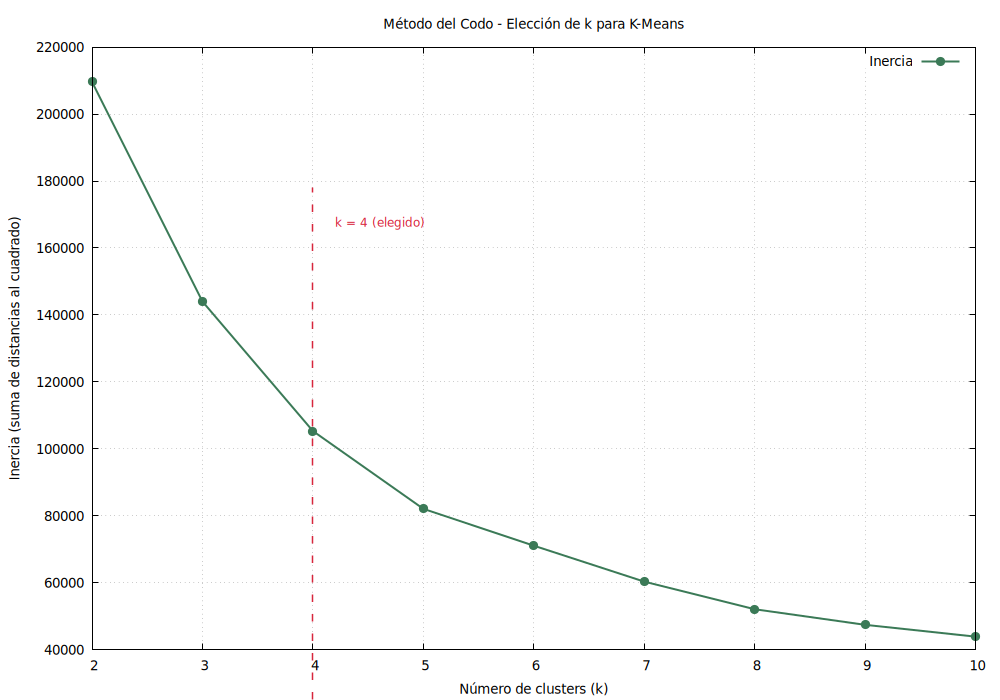

In [10]:
!gnuplot g1_codo_kmeans.gp
from IPython.display import Image, display
display(Image('g1_codo_kmeans.png'))


### Gráfico 2D N.º 2 — Mapa de clusters

Cada centro poblado coloreado según el cluster K-Means al que pertenece.

In [11]:
# Mapa de clusters: una serie 'plot' por cluster, con color y etiqueta
# (departamento dominante) tomados de PALETTE / cluster_top_dep.
plot_clauses = []
for c in range(K_FINAL):
    color = PALETTE[c % len(PALETTE)]
    label = f"Cluster {c} ({cluster_top_dep[c].title()})"
    plot_clauses.append(
        f"'centros_clusters.csv' every ::1 using ($11=={c} ? $9 : 1/0):10 "
        f"with points pointtype 7 pointsize 0.15 lc rgb '{color}' title '{label}'"
    )

gp_g2 = (
    "set terminal pngcairo size 1000,1300 enhanced font 'Verdana,10'\n"
    "set output 'g2_mapa_clusters.png'\n"
    "\n"
    f"set title 'Centros Poblados del Perú - Clusters K-Means (k={K_FINAL})'\n"
    "set xlabel 'Longitud'\n"
    "set ylabel 'Latitud'\n"
    "set grid\n"
    "set size ratio -1\n"
    "set datafile separator ','\n"
    "set key top right box\n"
    "plot " + ", ".join(plot_clauses) + "\n"
)
with open("g2_mapa_clusters.gp", "w") as f:
    f.write(gp_g2)
print(gp_g2)


set terminal pngcairo size 1000,1300 enhanced font 'Verdana,10'
set output 'g2_mapa_clusters.png'

set title 'Centros Poblados del Perú - Clusters K-Means (k=4)'
set xlabel 'Longitud'
set ylabel 'Latitud'
set grid
set size ratio -1
set datafile separator ','
set key top right box
plot 'centros_clusters.csv' every ::1 using ($11==0 ? $9 : 1/0):10 with points pointtype 7 pointsize 0.15 lc rgb '#3B7A57' title 'Cluster 0 (Ancash)', 'centros_clusters.csv' every ::1 using ($11==1 ? $9 : 1/0):10 with points pointtype 7 pointsize 0.15 lc rgb '#377BB5' title 'Cluster 1 (Puno)', 'centros_clusters.csv' every ::1 using ($11==2 ? $9 : 1/0):10 with points pointtype 7 pointsize 0.15 lc rgb '#B5451A' title 'Cluster 2 (Cajamarca)', 'centros_clusters.csv' every ::1 using ($11==3 ? $9 : 1/0):10 with points pointtype 7 pointsize 0.15 lc rgb '#8E44AD' title 'Cluster 3 (Lima)'



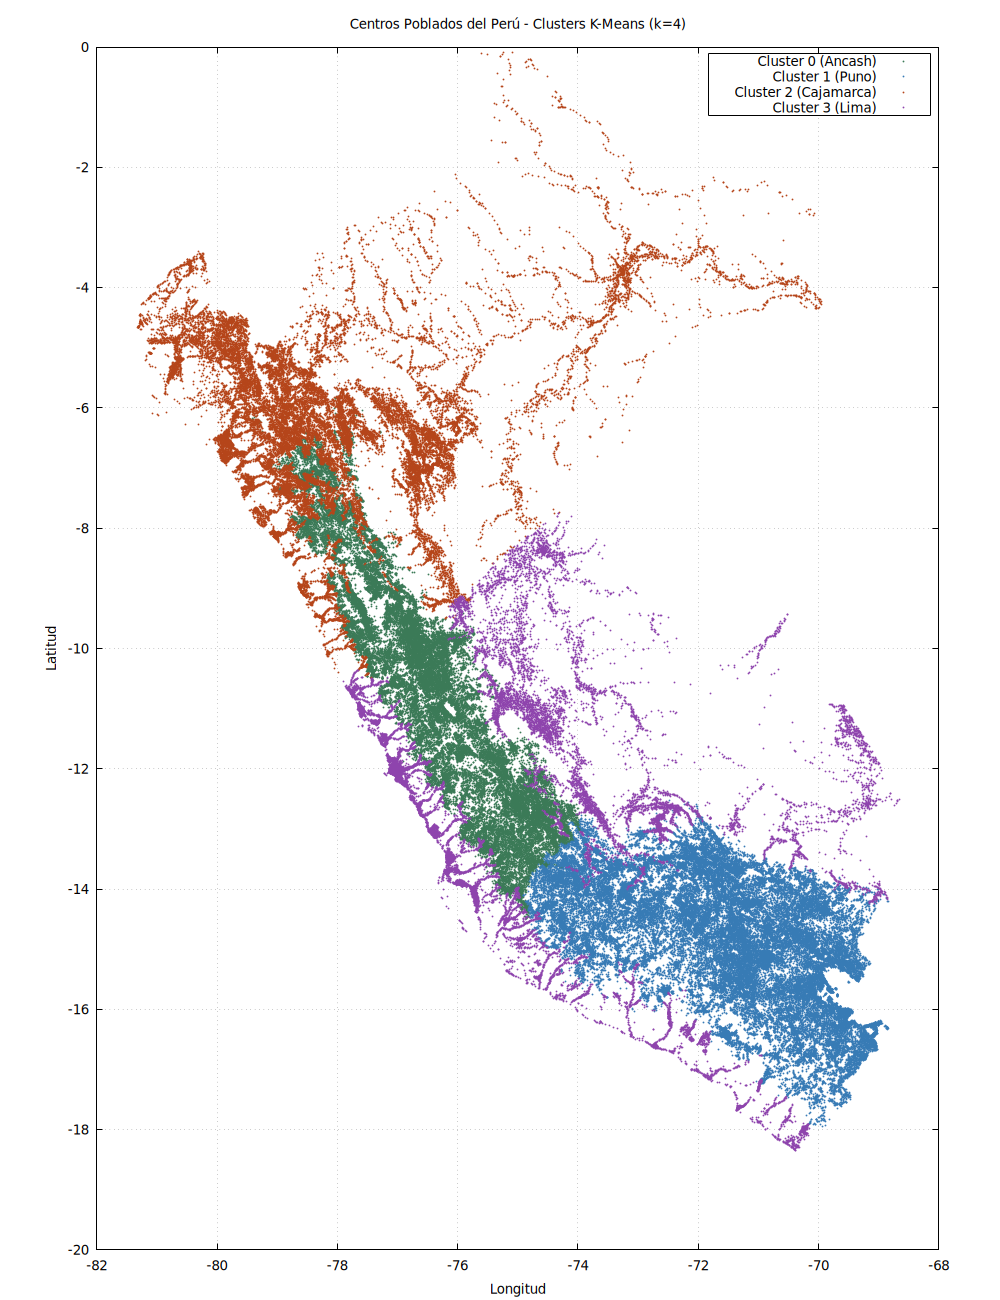

In [12]:
!gnuplot g2_mapa_clusters.gp
display(Image('g2_mapa_clusters.png'))


### Gráfico 2D N.º 3 — Tamaño de cada cluster

In [13]:
# Tamaño de cada cluster: xtics y barras generadas para K_FINAL clusters.
xtics_entries = []
plot_clauses = []
for c in range(K_FINAL):
    color = PALETTE[c % len(PALETTE)]
    label = f"Cluster {c}\\n({cluster_top_dep[c].title()})"
    xtics_entries.append(f'"{label}" {c}')
    plot_clauses.append(
        f"'resumen_clusters.csv' every ::{c + 1}::{c + 1} using ({c}):5 with boxes lc rgb '{color}'"
    )

gp_g3 = (
    "set terminal pngcairo size 900,700 enhanced font 'Verdana,10'\n"
    "set output 'g3_tamano_clusters.png'\n"
    "\n"
    "set title 'Tamaño de cada Cluster K-Means'\n"
    "set xlabel 'Cluster'\n"
    "set ylabel 'Número de centros poblados'\n"
    "set grid ytics\n"
    "set datafile separator ','\n"
    "set style fill solid 0.8 border -1\n"
    "set boxwidth 0.6\n"
    "set yrange [0:*]\n"
    "set key off\n"
    "set xtics (" + ", ".join(xtics_entries) + ")\n"
    "plot " + ", ".join(plot_clauses) + "\n"
)
with open("g3_tamano_clusters.gp", "w") as f:
    f.write(gp_g3)
print(gp_g3)


set terminal pngcairo size 900,700 enhanced font 'Verdana,10'
set output 'g3_tamano_clusters.png'

set title 'Tamaño de cada Cluster K-Means'
set xlabel 'Cluster'
set ylabel 'Número de centros poblados'
set grid ytics
set datafile separator ','
set style fill solid 0.8 border -1
set boxwidth 0.6
set yrange [0:*]
set key off
set xtics ("Cluster 0\n(Ancash)" 0, "Cluster 1\n(Puno)" 1, "Cluster 2\n(Cajamarca)" 2, "Cluster 3\n(Lima)" 3)
plot 'resumen_clusters.csv' every ::1::1 using (0):5 with boxes lc rgb '#3B7A57', 'resumen_clusters.csv' every ::2::2 using (1):5 with boxes lc rgb '#377BB5', 'resumen_clusters.csv' every ::3::3 using (2):5 with boxes lc rgb '#B5451A', 'resumen_clusters.csv' every ::4::4 using (3):5 with boxes lc rgb '#8E44AD'



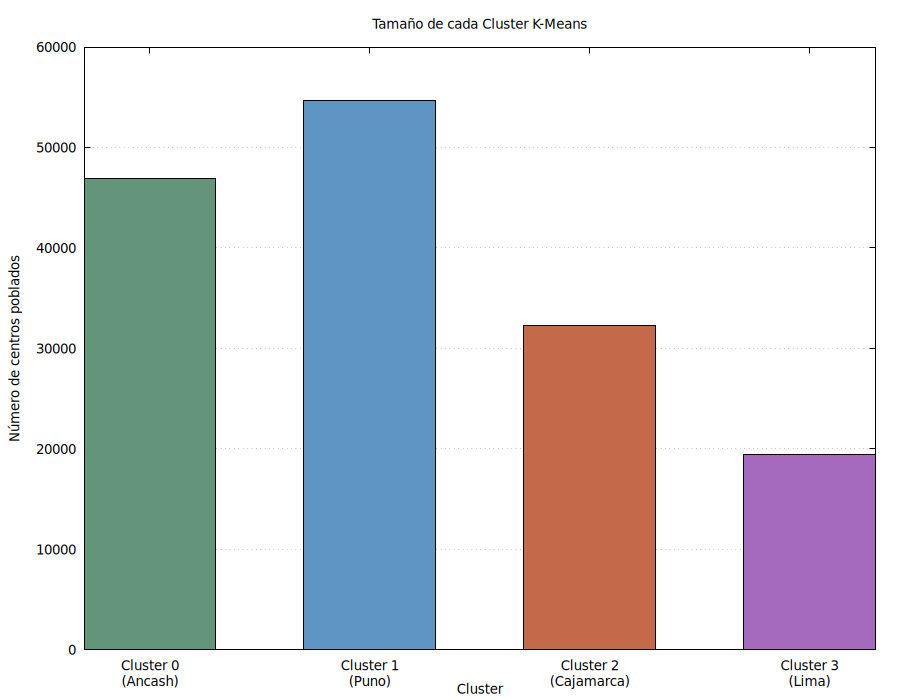

In [14]:
!gnuplot g3_tamano_clusters.gp
display(Image('g3_tamano_clusters.png'))


## 7. Visualización con GNU Plot — Gráfico 3D

### Dispersión 3D coloreada por cluster

Longitud, latitud y altitud a la vez: permite ver que los clusters también se separan por altitud, no solo por posición en el mapa.

In [15]:
# Dispersión 3D: misma lógica dinámica que el mapa 2D, agregando altitud (Z).
plot_clauses = []
for c in range(K_FINAL):
    color = PALETTE[c % len(PALETTE)]
    label = f"Cluster {c} ({cluster_top_dep[c].title()})"
    plot_clauses.append(
        f"'centros_clusters.csv' every ::1 using ($11=={c} ? $9 : 1/0):10:8 "
        f"with points pointtype 7 pointsize 0.15 lc rgb '{color}' title '{label}'"
    )

gp_g4 = (
    "set terminal pngcairo size 1100,900 enhanced font 'Verdana,10'\n"
    "set output 'g4_dispersion_3d_clusters.png'\n"
    "\n"
    f"set title 'Centros Poblados del Perú - Clusters K-Means en 3D (k={K_FINAL})'\n"
    "set xlabel 'Longitud' offset 0,-1\n"
    "set ylabel 'Latitud' offset -2,0\n"
    "set zlabel 'Altitud (m.s.n.m.)' rotate by 90 offset -2,0\n"
    "set grid\n"
    "set datafile separator ','\n"
    "set view 55,300\n"
    "set ticslevel 0\n"
    "set key top right box\n"
    "splot " + ", ".join(plot_clauses) + "\n"
)
with open("g4_dispersion_3d_clusters.gp", "w") as f:
    f.write(gp_g4)
print(gp_g4)


set terminal pngcairo size 1100,900 enhanced font 'Verdana,10'
set output 'g4_dispersion_3d_clusters.png'

set title 'Centros Poblados del Perú - Clusters K-Means en 3D (k=4)'
set xlabel 'Longitud' offset 0,-1
set ylabel 'Latitud' offset -2,0
set zlabel 'Altitud (m.s.n.m.)' rotate by 90 offset -2,0
set grid
set datafile separator ','
set view 55,300
set ticslevel 0
set key top right box
splot 'centros_clusters.csv' every ::1 using ($11==0 ? $9 : 1/0):10:8 with points pointtype 7 pointsize 0.15 lc rgb '#3B7A57' title 'Cluster 0 (Ancash)', 'centros_clusters.csv' every ::1 using ($11==1 ? $9 : 1/0):10:8 with points pointtype 7 pointsize 0.15 lc rgb '#377BB5' title 'Cluster 1 (Puno)', 'centros_clusters.csv' every ::1 using ($11==2 ? $9 : 1/0):10:8 with points pointtype 7 pointsize 0.15 lc rgb '#B5451A' title 'Cluster 2 (Cajamarca)', 'centros_clusters.csv' every ::1 using ($11==3 ? $9 : 1/0):10:8 with points pointtype 7 pointsize 0.15 lc rgb '#8E44AD' title 'Cluster 3 (Lima)'



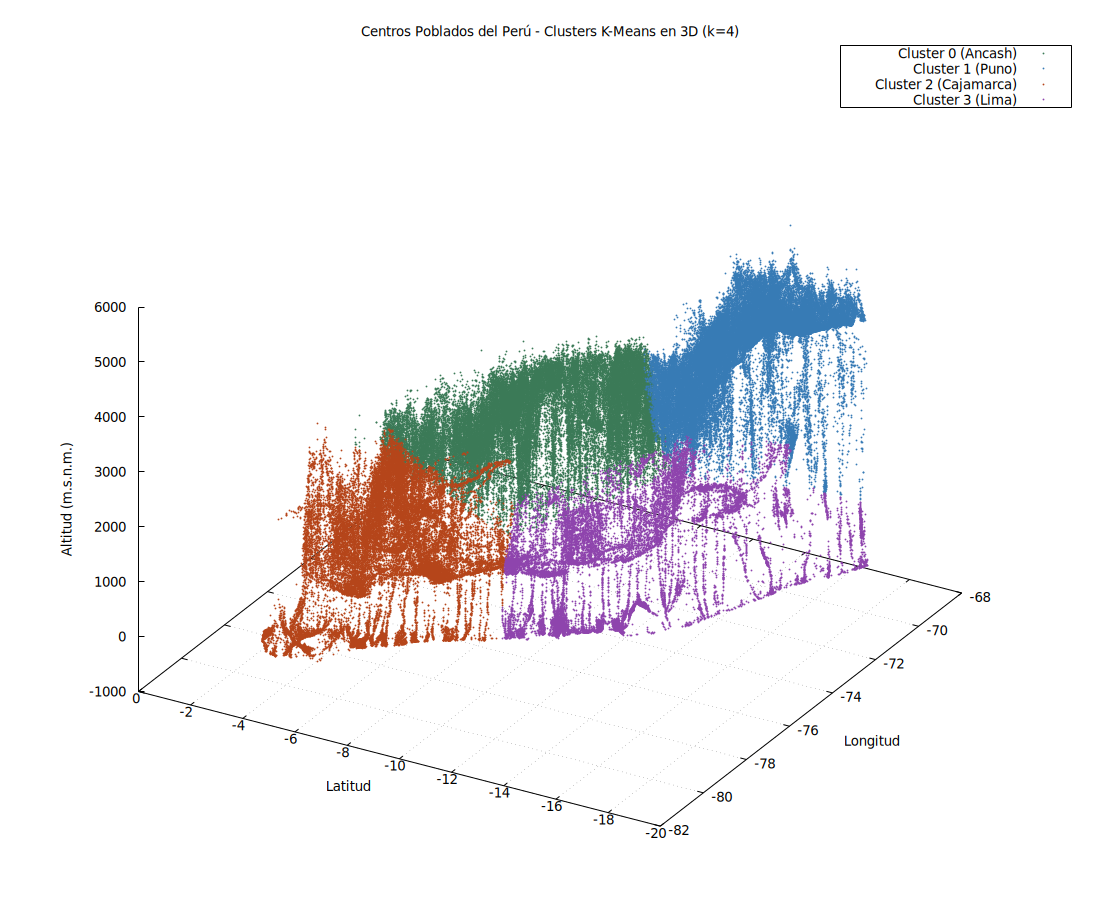

In [16]:
!gnuplot g4_dispersion_3d_clusters.gp
display(Image('g4_dispersion_3d_clusters.png'))


## 8. Conclusiones

Resultados con el shapefile real `CP_P.shp` (INEI/IGN): **153,331 centros poblados** (153,400 originales, menos 69 sin `DEP` asignado) en **25 departamentos** (incluye Callao; Lima Metropolitana y Lima provincias comparten la etiqueta `LIMA`).

**Elección de k e interpretación geográfica**

- El método del codo, combinado con el silhouette score en el rango interpretable 3–6, sugiere **k = 4**: la inercia cae con fuerza de k=2 a k=4 y luego se aplana, y k=4 tiene el mejor silhouette (≈0.44) dentro de ese rango. El silhouette es moderado (no cercano a 1) en todos los k probados, lo cual es esperable: la geografía real no forma grupos perfectamente separados, sino un continuo de costa a sierra.
- Los 4 clusters, sin usar la etiqueta `DEP`, quedan así:
  - **Cluster 0** (46,918 CP, 30.6%) — dominado por Áncash, Huancavelica, Huánuco; altitud media ≈3,587 m.
  - **Cluster 1** (54,642 CP, 35.6%) — dominado por Puno, Cusco, Ayacucho; altitud media ≈3,888 m (la más alta).
  - **Cluster 2** (32,282 CP, 21.1%) — dominado por Cajamarca, San Martín, Piura; altitud media ≈1,077 m.
  - **Cluster 3** (19,489 CP, 12.7%) — dominado por Lima, Ica, Junín; altitud media ≈733 m (la más baja).
- A diferencia de una separación limpia "costa / sierra / selva", con datos reales los clusters se organizan como **franjas geográficas orientadas noroeste–sureste combinadas con altitud**: dos bloques de sierra alta (0 y 1, que dividen el país en sierra centro-norte vs. sierra sur) y dos bloques más bajos (2 en el norte, con costa y selva norte mezcladas, y 3 en el centro-sur, con costa y valles interandinos bajos).
- Esto también hace que **algunos departamentos queden partidos entre dos clusters**: Lima tiene 5,518 centros poblados en el Cluster 0 (sierra) y 4,429 en el Cluster 3 (costa/valles bajos); Junín se reparte de forma parecida (5,202 en sierra alta, 1,874 en valles bajos). Esto es coherente con la geografía real de esos departamentos, que abarcan tanto costa/valle como sierra alta.
- Como K-Means usa distancia euclidiana, favorece clusters compactos y de forma más o menos convexa; por eso no reproduce exactamente las tres macrorregiones tradicionales (costa/sierra/selva), que son alargadas y no convexas, sino una partición en franjas que combina posición geográfica y altitud.

**¿Qué tan bien coincide con los departamentos? (validación cuantitativa)**

- El acuerdo formal entre `cluster` y `DEP` (sección 5.1) es **moderado**: Adjusted Rand Index ≈ 0.20 y Normalized Mutual Information ≈ 0.44. Confirma en números lo que muestran los mapas: K-Means, usando solo 3 variables numéricas, captura una porción real pero parcial de la estructura departamental — y de hecho capta variación *dentro* de un mismo departamento (no solo *entre* departamentos), como el caso de Lima y Junín.

**Lo que muestran `CON_IE` y `CAPITAL` sin haberlas usado en el clustering**

- `CON_IE` (centro poblado con institución educativa) **sí varía bastante entre clusters**: de 12.7% en el Cluster 1 (sierra sur, la más alta y con más centros poblados) a 39.8% en el Cluster 2 (norte, altitud media). Esta brecha —cerca del triple de cobertura educativa en el cluster de menor altitud que en el de mayor altitud— sugiere que la altitud/aislamiento geográfico capturado por el cluster **sí sería un buen predictor de cobertura educativa**, y es evidencia a favor de la recomendación de abajo sobre usar los clusters para análisis posteriores.
- `CAPITAL` (si el centro poblado es capital de distrito/provincia/departamento) en cambio es **casi uniforme entre clusters** (entre 0.85% y 1.64% son alguna capital, en los cuatro), porque las capitales están distribuidas proporcionalmente por todo el territorio. Esto sugiere que, agregada como variable de clustering, `CAPITAL` aportaría poca señal geográfica adicional — a diferencia de `CON_IE`.

## 9. Recomendaciones

**Sobre el modelo**

- Probar agregar más variables al clustering (ej. `CON_IE`, `CAPITAL`) para ver si aportan una segmentación adicional relevante. La exploración de la sección 5.1 ya da una pista de por dónde empezar: `CON_IE` varía mucho entre clusters geográficos (12.7%–39.8%) y podría aportar señal real si se incluye como feature (probablemente separando centros poblados más/menos atendidos dentro de una misma franja geográfica); `CAPITAL` en cambio está casi parejo (~0.85%–1.64%) en los cuatro clusters, así que es poco probable que por sí sola cambie mucho la partición — conviene priorizar `CON_IE` y variables derivadas de `NIVEL` antes que `CAPITAL`.
- Repetir el pipeline con una proyección UTM (o distancia haversine) en vez de grados geográficos (`XGD`/`YGD`) para que 1 unidad de distancia signifique lo mismo en longitud y en latitud a estas latitudes; esto podría ayudar a que los clusters sigan más de cerca las franjas costa/sierra/selva.
- Probar un algoritmo que no asuma clusters convexos (ej. DBSCAN, HDBSCAN o clustering espectral) y comparar su Adjusted Rand Index / Normalized Mutual Information contra `DEP` con el de K-Means, ya que la geografía real (costa/sierra/selva) es alargada y no convexa.
- Evaluar la estabilidad del resultado corriendo K-Means con distintas semillas (`random_state`) o sobre submuestras (bootstrap) y midiendo qué tan parecidas salen las particiones; esto da una idea de qué tan robusta es la elección de k=4 y de los límites entre clusters.

**Sobre el uso de los resultados**

- Usar los clusters resultantes como variable de agrupación para análisis posteriores (ej. cobertura educativa por cluster geográfico), aprovechando que la regionalización obtenida corta transversalmente algunos departamentos. La brecha de `CON_IE` encontrada en 5.1 (12.7% vs. 39.8%) es un primer ejemplo concreto de este tipo de análisis y sugiere que vale la pena profundizar por cluster (y no solo por departamento) al estudiar acceso a servicios.
- Si el objetivo final es apoyar decisiones de política pública (p. ej. focalización de inversión en infraestructura educativa), complementar esta regionalización automática con criterios administrativos existentes (UGEL, redes educativas) en vez de reemplazarlos, ya que el clustering agrupa por geografía y altitud, no por gestión territorial.
- Sustituir el shapefile por una versión actualizada del INEI/IGN cuando esté disponible, y volver a correr el notebook completo (el pipeline ya está parametrizado en `K_FINAL`, sin valores fijos) para verificar si la estructura de clusters se mantiene con datos más recientes.